# CIFAR-10 classification: one CNN, three implementations

This notebook builds a convolutional neural network that classifies small
color photographs into one of ten everyday object categories (airplane,
automobile, bird, cat, deer, dog, frog, horse, ship, truck), and it builds
that same network three separate times: once with every operation written
by hand in NumPy, once with TensorFlow/Keras, and once with PyTorch. The
architecture, the data split, and every training hyperparameter are held
fixed across the three implementations, so any difference in the results
comes from the implementation itself.

Each image here is 32 by 32 pixels across three color channels (red, green,
blue). A convolution's kernel has to span all three input channels at once
at the first layer, summing across red, green, and blue simultaneously
rather than sliding over a single plane of values, which is one of the
places this notebook's scratch implementation gets its own independent
numerical verification below rather than being assumed correct just because
the same general approach is a well-established one.

The data here has local spatial structure, neighboring pixels are far more
likely to belong to the same object or texture than two distant pixels are,
which is exactly what a convolution is built to exploit, so the shared
architecture here is a CNN rather than a plain feedforward network.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import json
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Loading the data

CIFAR-10 loads through Keras's own dataset loader, so there's no manual
download step here. The loaded arrays are reused by all three
implementations below, so every implementation trains on and is evaluated
against the exact same images in the exact same order.

In [3]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("Train:", X_train_raw.shape, y_train.shape)
print("Test:", X_test_raw.shape, y_test.shape)
print("Pixel range before normalization:", X_train_raw.min(), "to", X_train_raw.max())

Train: (50000, 32, 32, 3) (50000,)
Test: (10000, 32, 32, 3) (10000,)
Pixel range before normalization: 0 to 255


## Data understanding

Class balance first, then a look at actual images, then the pixel
distribution, before assuming a well-known benchmark dataset needs no
scrutiny.

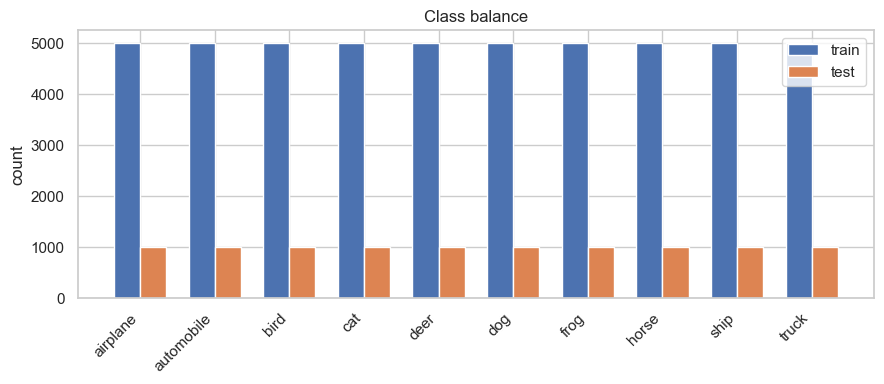

In [4]:
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

plt.figure(figsize=(9, 4))
x = np.arange(10)
width = 0.35
plt.bar(x - width/2, train_counts, width, label="train")
plt.bar(x + width/2, test_counts, width, label="test")
plt.xticks(x, CLASS_NAMES, rotation=45, ha="right")
plt.ylabel("count")
plt.title("Class balance")
plt.legend()
plt.tight_layout()
plt.show()

Every class has exactly 5,000 training images and 1,000 test images, so
this is a balanced benchmark dataset and no class-weighting correction is
needed here: a model that just predicted one class every time would only
get 10% accuracy, not a deceptively high number the way it would on an
imbalanced target.

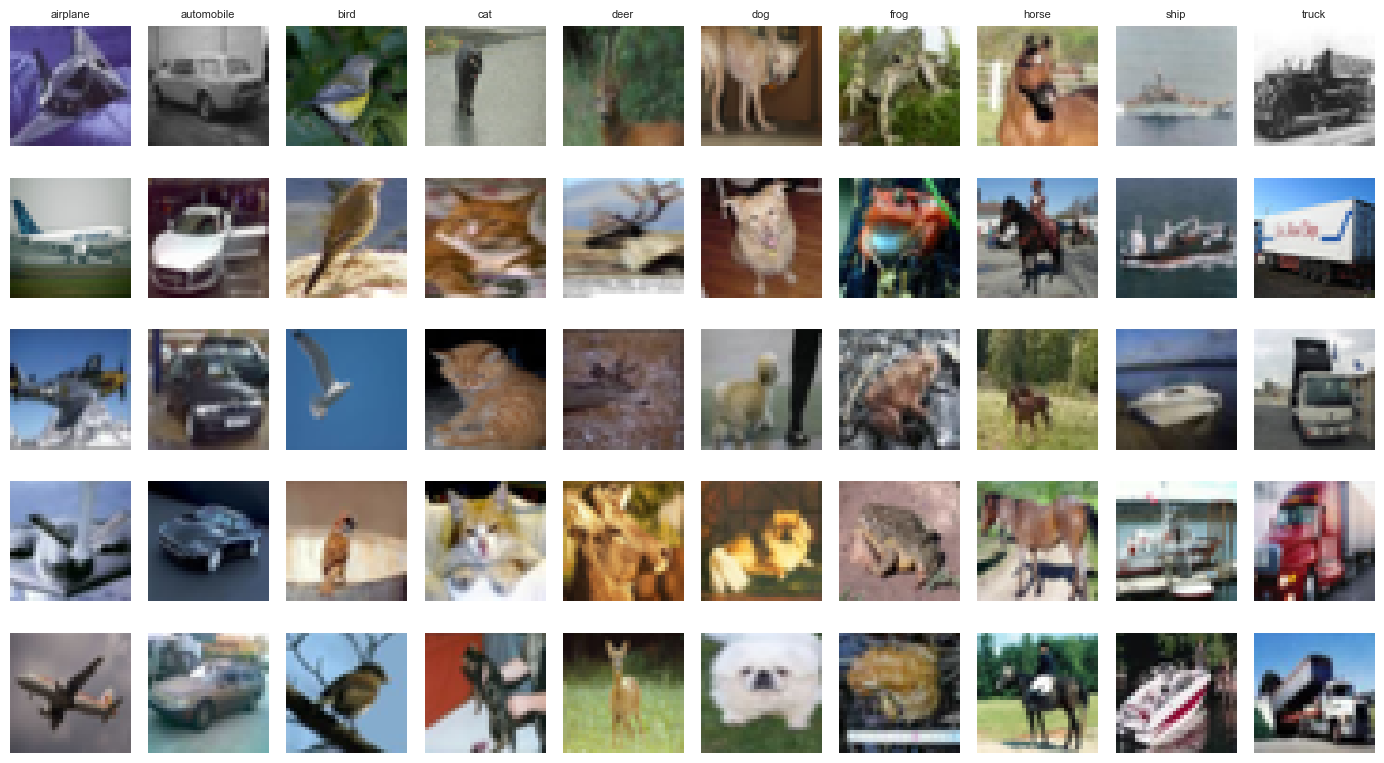

In [5]:
fig, axes = plt.subplots(5, 10, figsize=(14, 8))
rng = np.random.default_rng(RANDOM_SEED)
for class_idx in range(10):
    class_examples = np.where(y_train == class_idx)[0]
    chosen = rng.choice(class_examples, size=5, replace=False)
    for row, example_idx in enumerate(chosen):
        ax = axes[row, class_idx]
        ax.imshow(X_train_raw[example_idx])
        ax.axis("off")
        if row == 0:
            ax.set_title(CLASS_NAMES[class_idx], fontsize=8)
plt.tight_layout()
plt.show()

These are real color photographs at only 32x32 resolution, small enough
that a lot of fine detail is lost, and some category pairs (cat/dog,
automobile/truck) are genuinely ambiguous even at full resolution. A
meaningfully lower accuracy on this data than on a simpler grayscale
classification problem would be expected from the dataset's own difficulty,
not necessarily a sign that a model did anything wrong.

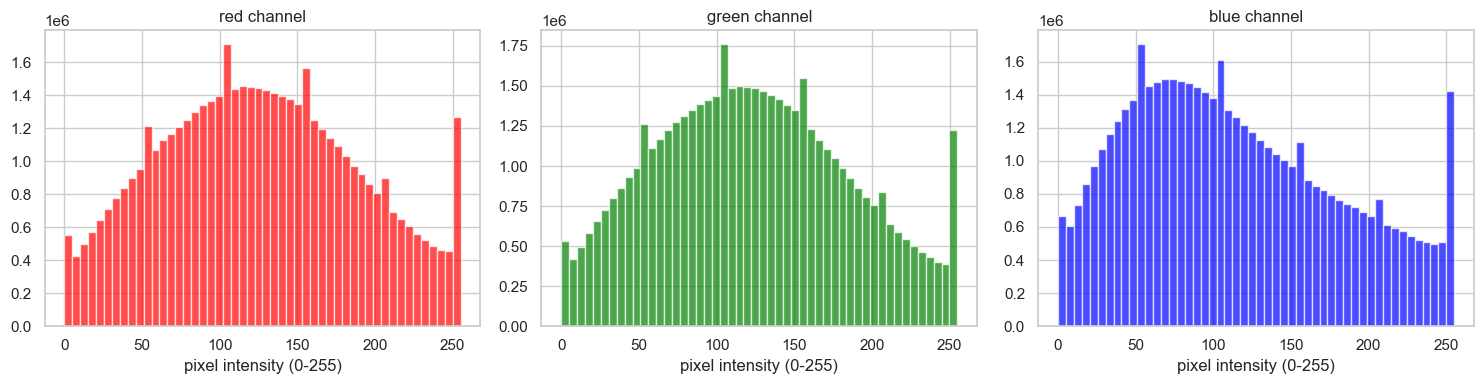

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["red", "green", "blue"]
for i, (ax, color) in enumerate(zip(axes, colors)):
    ax.hist(X_train_raw[:, :, :, i].flatten(), bins=50, color=color, alpha=0.7)
    ax.set_title(f"{color} channel")
    ax.set_xlabel("pixel intensity (0-255)")
plt.tight_layout()
plt.show()

All three channels span the full 0-255 range with a broadly similar shape,
which is what's expected of natural color photographs (no channel is
saturated or degenerate), and confirms normalizing all three channels the
same way below is reasonable.

## Representation

Two steps before this data is ready to train on: rescale pixel values from
0-255 to 0.0-1.0, and lay the array out in the channel order each
implementation expects. A convolution kernel has a shape like
`(out_channels, in_channels, kh, kw)`, so the input array has to carry an
explicit channel axis (3 here, one each for red, green, blue) for the
operation to know how many channels to sum over. No train-only-fit
statistic is needed for the rescaling itself, since dividing by a fixed
constant uses no information from the data, so there's nothing that could
leak from the test set into it.

Scratch and PyTorch use channel-first tensors, `(N, 3, 32, 32)`, matching
`nn.Conv2d`'s own expected input shape. Keras uses channel-last, `(N, 32,
32, 3)`, which happens to be the layout CIFAR-10 already ships in (the
same channels-last convention plain image libraries like PIL and NumPy
normally use), so no transpose is needed for the Keras version, only for
the scratch/PyTorch ones. Neither ordering is mathematically better than
the other; it's a framework default, not a requirement, applied to the
exact same normalized pixel values either way.

In [7]:
X_train_norm = X_train_raw.astype(np.float32) / 255.0
X_test_norm = X_test_raw.astype(np.float32) / 255.0

# Channel-last (as shipped), for Keras: (N, 32, 32, 3)
X_train_hwc = X_train_norm
X_test_hwc = X_test_norm

# Channel-first, for scratch and PyTorch: (N, 3, 32, 32)
X_train_chw = X_train_norm.transpose(0, 3, 1, 2).copy()
X_test_chw = X_test_norm.transpose(0, 3, 1, 2).copy()

y_train_int = y_train.astype(np.int64)
y_test_int = y_test.astype(np.int64)

print("Channel-first shape:", X_train_chw.shape)
print("Channel-last shape:", X_train_hwc.shape)
print("Confirmed 50,000 train / 10,000 test:", X_train_chw.shape[0] == 50000, X_test_chw.shape[0] == 10000)

Channel-first shape: (50000, 3, 32, 32)
Channel-last shape: (50000, 32, 32, 3)
Confirmed 50,000 train / 10,000 test: True True


## Shared architecture

This is a direct instance of the CNN architecture the course material's own
tutorial works out in full for a `3x32x32` input:

```
3x32x32 -> Conv(3->32, k=3, pad=1) -> ReLU -> MaxPool(2)
        -> Conv(32->64, k=3, pad=1) -> ReLU -> MaxPool(2)
        -> Flatten (64*8*8 = 4096) -> Linear(4096->128) -> ReLU -> Linear(128->10)
```

Shape trace: `(B,3,32,32) -> (B,32,32,32) -> (B,32,16,16) -> (B,64,16,16) ->
(B,64,8,8) -> (B,4096) -> (B,128) -> (B,10)`, matching the tutorial's own
worked shape progression exactly.

Batch size, epochs, and learning rate are fixed once here, reused unchanged
by all three implementations, with plain SGD (no momentum, no Adam) as the
optimizer everywhere: this keeps the optimizer's own update rule identical
across all three implementations without needing a from-scratch Adam
implementation to make that comparison fair.

In [8]:
BATCH_SIZE = 256
EPOCHS = 12
LEARNING_RATE = 0.05
NUM_CLASSES = 10

print(f"Batch size: {BATCH_SIZE}, epochs: {EPOCHS}, learning rate: {LEARNING_RATE}")
print(f"Batches per epoch: {int(np.ceil(50000 / BATCH_SIZE))}")

Batch size: 256, epochs: 12, learning rate: 0.05
Batches per epoch: 196


## Implementation 1: from scratch, NumPy only

Every operation in this section is implemented by hand. Nothing here
imports TensorFlow, Keras, or PyTorch.

### Convolution

Before any code, here is what a convolution actually does, mechanically:

1. A kernel is a small grid of learned numbers. In a single-channel image
   it would be, say, 3x3; here it is `3x3x3`, a 3x3 spatial grid repeated
   once per color channel, to match the input's red, green, and blue.
2. That block gets lined up against a `3x3x3` patch of the image: a 3x3
   square of pixels, each pixel carrying its own red, green, and blue
   value.
3. Every overlapping pair (one kernel number, one channel value under
   it), 27 pairs in total, gets multiplied together.
4. All 27 products get added into a single number.
5. That number becomes one entry in a new, smaller grid, the feature map.
6. The kernel slides one pixel over, and steps 2 through 5 repeat, until
   every position has produced one entry.

**A single-channel worked example** makes the core mechanic concrete
before putting the color dimension back in, using a smaller 2x2 kernel
purely so the arithmetic stays short:

- Kernel `[[1, 0], [0, -1]]`, patch `[[1, 2], [4, 5]]`, from one channel.
- Multiply position by position: `1*1`, `0*2`, `0*4`, `-1*5`.
- Add the four products: `1 + 0 + 0 - 5 = -4`, one number for one
  output position.

With 3 input channels instead of 1, the same idea just repeats once per
channel, and the three channels' results get added together into that
same single output number, which is exactly what summing over `C_in` in
the formula below does.

**Why bother at all**, rather than feeding every pixel straight into a
plain dense layer: the same kernel gets reused at every position across
the whole image. A kernel whose numbers happen to detect a particular
color edge or texture produces a large value wherever that pattern
appears, without needing a separate detector learned specifically for
each location. That reuse, weight sharing, is what lets one small kernel
generalize across an entire image.

**The general formula**, for output channel `f` and output position
`(i, j)`:

```
Y[f,i,j] = sum(K[f] * patch) + b[f]
```

where `patch` is the `(C_in, k, k)` chunk of the (padded) input lined up
under the kernel at that position, summed over all `C_in` input channels
at once. This network's first layer has `C_in = 3`, so its kernel has
shape `(32, 3, 3, 3)` rather than a single-channel network's `(32, 1, 3,
3)`. The functions below are written generically in terms of `C_in`, so
the same code handles any number of input channels without a separate
code path for the 3-channel case, but that genericity gets verified
directly below with a gradient check on a synthetic 3-channel input,
rather than just assumed from the code looking reasonable.

**A performance detail sits on top of that same operation**, not a
second concept: a straightforward implementation loops over every output
position and computes that sum there, one position at a time, which
benchmarks too slowly to be practical on this network's real layer sizes.
The fix used below, `im2col`, computes the exact same multiply-and-add
for every position at once instead of one at a time: every patch the
kernel will ever land on gets extracted up front (as a zero-copy strided
view, via numpy's `as_strided`), stacked into one big matrix, and
multiplied against the reshaped kernel in a single matrix multiplication.
Max pooling below uses a similar reshape-based trick, and the
convolution's backward pass uses a `col2im`-style scatter-accumulate,
looping only over the kernel's own small spatial extent rather than every
output position.

In [9]:
def conv2d_forward(X, K, b, stride=1, padding=1):
    N, C_in, H, W = X.shape
    C_out, _, kh, kw = K.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    Ho = (H + 2 * padding - kh) // stride + 1
    Wo = (W + 2 * padding - kw) // stride + 1

    s0, s1, s2, s3 = Xp.strides
    patch_shape = (N, C_in, Ho, Wo, kh, kw)
    patch_strides = (s0, s1, s2 * stride, s3 * stride, s2, s3)
    patches = np.lib.stride_tricks.as_strided(Xp, shape=patch_shape, strides=patch_strides)

    col = patches.transpose(0, 2, 3, 1, 4, 5).reshape(N * Ho * Wo, C_in * kh * kw).copy()
    Kmat = K.reshape(C_out, C_in * kh * kw)

    out = col @ Kmat.T + b
    Y = out.reshape(N, Ho, Wo, C_out).transpose(0, 3, 1, 2)

    cache = {"X_shape": X.shape, "col": col, "K_shape": K.shape,
             "stride": stride, "padding": padding, "Ho": Ho, "Wo": Wo}
    return Y, cache


def conv2d_backward(dY, K, cache):
    N, C_in, H, W = cache["X_shape"]
    C_out, _, kh, kw = cache["K_shape"]
    stride, padding = cache["stride"], cache["padding"]
    Ho, Wo, col = cache["Ho"], cache["Wo"], cache["col"]

    dY_r = dY.transpose(0, 2, 3, 1).reshape(N * Ho * Wo, C_out)
    Kmat = K.reshape(C_out, C_in * kh * kw)

    dK = (dY_r.T @ col).reshape(C_out, C_in, kh, kw)
    db = dY_r.sum(axis=0)

    dcol = dY_r @ Kmat
    dcol_r = dcol.reshape(N, Ho, Wo, C_in, kh, kw)

    Hp, Wp = H + 2 * padding, W + 2 * padding
    dXp = np.zeros((N, C_in, Hp, Wp), dtype=dY.dtype)
    for u in range(kh):
        for v in range(kw):
            dXp[:, :, u:u + Ho * stride:stride, v:v + Wo * stride:stride] += \
                dcol_r[:, :, :, :, u, v].transpose(0, 3, 1, 2)

    dX = dXp[:, :, padding:Hp - padding, padding:Wp - padding] if padding > 0 else dXp
    return dX, dK, db

### Max pooling

Max pooling shrinks the spatial size by keeping only the largest value in
each small window (2x2 here, non-overlapping) and discarding the rest.

**A worked example.** Take one 2x2 window with values `[[1, 3], [2, 0]]`.
Max pooling looks at all four numbers, keeps the largest, `3`, at position
`(0, 1)`, and discards the other three. A 2x2 window like this one always
divides evenly, so pooling every window across the whole feature map can
be done with a single reshape instead of a loop: `(N, C, H, W)` reshapes
to `(N, C, H/2, 2, W/2, 2)`, and taking the max over the two size-2 axes
produces exactly this same result, for every window at once.

**Backward** needs to know which position inside each window was the
maximum, because the gradient of a max function is `1` at the maximizing
input and `0` everywhere else: a small change to any of the three
non-maximum values in a window wouldn't have changed the window's output
at all, so none of them get any gradient. Continuing the example above,
if the gradient flowing back into this window's single output is `5`,
that `5` goes entirely to position `(0, 1)` (where the `3` was), and the
other three positions each receive `0`. The forward pass below saves a
mask marking those maximizing positions, and backward multiplies the
incoming gradient by that mask, so it only flows to the position that
actually determined the output.

In [10]:
def max_pool2d_forward(X, size=2, stride=2):
    N, C, H, W = X.shape
    Ho, Wo = H // stride, W // stride
    X_windows = X.reshape(N, C, Ho, stride, Wo, stride)
    Y = X_windows.max(axis=(3, 5))
    mask = (X_windows == Y.reshape(N, C, Ho, 1, Wo, 1))
    cache = {"X_shape": X.shape, "mask": mask, "stride": stride}
    return Y, cache


def max_pool2d_backward(dY, cache):
    N, C, H, W = cache["X_shape"]
    stride, mask = cache["stride"], cache["mask"]
    Ho, Wo = H // stride, W // stride
    dY_windows = dY.reshape(N, C, Ho, 1, Wo, 1)
    dX = (mask * dY_windows).reshape(N, C, H, W)
    return dX

### ReLU, flatten, and the dense layers

`relu`/`relu_derivative` handle the nonlinearity: `max(0, x)` passes
positive values through and zeroes out negative ones, with a derivative
of 1 where the input was positive and 0 where it wasn't.
`flatten_forward`/`flatten_backward` are a pure reshape with no learned
parameters. `linear_forward`/`linear_backward` are the dense layers,
`Y = x @ W + b`.

One detail in `linear_backward` is worth being precise about: the loss is
a *mean* over the batch, and that averaging happens exactly once, at the
point where the loss gradient is first computed (below, inside
`softmax_cross_entropy_backward`). Every gradient computed afterward, as
it flows backward through the dense layers, the pooling layers, and the
convolutions, already carries that averaging with it via the chain rule.
So `linear_backward` does not divide by the batch size again: a layer's
weight gradient is `x.T @ dY`, and its bias gradient is `dY` summed over
the batch, with no extra division. Dividing a second time at every layer
would silently shrink the gradients reaching the earlier layers, exactly
the kind of bug the gradient check below exists to catch.

In [11]:
def relu(z):
    return np.maximum(0.0, z)


def relu_derivative(z):
    return (z > 0).astype(z.dtype)


def flatten_forward(X):
    shape = X.shape
    return X.reshape(shape[0], -1), shape


def flatten_backward(dflat, shape):
    return dflat.reshape(shape)


def linear_forward(x, W, b):
    Y = x @ W + b
    cache = {"x": x, "W": W}
    return Y, cache


def linear_backward(dY, cache):
    x, W = cache["x"], cache["W"]
    dW = x.T @ dY
    db = np.sum(dY, axis=0, keepdims=True)
    dx = dY @ W.T
    return dx, dW, db

### Loss: softmax cross-entropy

This is a 10-class problem, so the output layer needs softmax rather than
sigmoid: it turns 10 raw scores (logits) into 10 probabilities that sum to
1, one per class, via `probs[i] = exp(logits[i]) / sum(exp(logits))`.

**A worked example**, with 3 classes instead of 10 so the numbers stay
readable. Say the logits are `[2.0, 1.0, 0.1]` and the true class is
class 0:

- `exp(2.0) ≈ 7.39`, `exp(1.0) ≈ 2.72`, `exp(0.1) ≈ 1.11`, summing to
  `≈ 11.22`.
- Dividing each by that sum gives probabilities `≈ [0.66, 0.24, 0.10]`.
- Cross-entropy only looks at the probability assigned to the true
  class: `loss = -log(0.66) ≈ 0.42`.
- Had the model instead put most of its probability on the wrong class,
  say `probs ≈ [0.10, 0.66, 0.24]` for the same true class 0, the loss
  would be `-log(0.10) ≈ 2.30`, over 5 times larger for being confidently
  wrong instead of confidently right.

**The gradient** of softmax combined with cross-entropy collapses to
`probs - one_hot(y)`, the predicted probability vector minus 1 at the
true class's position. In the first worked example above, that gradient
would be `[0.66 - 1, 0.24, 0.10] = [-0.34, 0.24, 0.10]`: negative at the
true class (push its probability up), positive everywhere else (push
those probabilities down). That's computed directly below, divided by
the batch size `N` right here, once, since the loss itself is a mean
over the batch.

In [12]:
def softmax_cross_entropy_forward(logits, y_true_idx):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    correct_logprobs = -np.log(np.clip(probs[np.arange(N), y_true_idx], 1e-9, 1.0))
    loss = np.mean(correct_logprobs)
    return loss, probs


def softmax_cross_entropy_backward(probs, y_true_idx):
    N = probs.shape[0]
    dlogits = probs.copy()
    dlogits[np.arange(N), y_true_idx] -= 1
    dlogits /= N
    return dlogits

### Putting it together: forward, backward, and a gradient check

`forward` composes every function above in the order the architecture
specifies: convolution, ReLU, pool, convolution, ReLU, pool, flatten,
dense, ReLU, dense, caching everything each layer's backward pass will
need. `backward` walks that exact same list of layers in reverse, which
is why its code below reads, top to bottom, as the mirror image of
`forward`'s: the last thing `forward` did (the second dense layer) is the
first thing `backward` undoes, and the first thing `forward` did (the
first convolution) is the last thing `backward` reaches.

In [13]:
def init_params(seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    params = {
        "K1": rng.standard_normal((32, 3, 3, 3)) * np.sqrt(2.0 / (3 * 3 * 3)),
        "b1": np.zeros(32),
        "K2": rng.standard_normal((64, 32, 3, 3)) * np.sqrt(2.0 / (32 * 3 * 3)),
        "b2": np.zeros(64),
        "W1": rng.standard_normal((64 * 8 * 8, 128)) * np.sqrt(2.0 / (64 * 8 * 8)),
        "b1_dense": np.zeros((1, 128)),
        "W2": rng.standard_normal((128, NUM_CLASSES)) * np.sqrt(2.0 / 128),
        "b2_dense": np.zeros((1, NUM_CLASSES)),
    }
    return params


def forward(X, params):
    Z1, conv1_cache = conv2d_forward(X, params["K1"], params["b1"], stride=1, padding=1)
    A1 = relu(Z1)
    P1, pool1_cache = max_pool2d_forward(A1, size=2, stride=2)

    Z2, conv2_cache = conv2d_forward(P1, params["K2"], params["b2"], stride=1, padding=1)
    A2 = relu(Z2)
    P2, pool2_cache = max_pool2d_forward(A2, size=2, stride=2)

    flat, flat_shape = flatten_forward(P2)
    Z3, lin1_cache = linear_forward(flat, params["W1"], params["b1_dense"])
    A3 = relu(Z3)
    logits, lin2_cache = linear_forward(A3, params["W2"], params["b2_dense"])

    cache = {
        "Z1": Z1, "conv1_cache": conv1_cache, "pool1_cache": pool1_cache,
        "Z2": Z2, "conv2_cache": conv2_cache, "pool2_cache": pool2_cache,
        "flat_shape": flat_shape, "Z3": Z3, "lin1_cache": lin1_cache, "lin2_cache": lin2_cache,
    }
    return logits, cache


def backward(y_true_idx, probs, cache, params):
    dlogits = softmax_cross_entropy_backward(probs, y_true_idx)
    dA3, dW2, db2_dense = linear_backward(dlogits, cache["lin2_cache"])
    dZ3 = dA3 * relu_derivative(cache["Z3"])
    dflat, dW1, db1_dense = linear_backward(dZ3, cache["lin1_cache"])

    dP2 = flatten_backward(dflat, cache["flat_shape"])
    dA2 = max_pool2d_backward(dP2, cache["pool2_cache"])
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dP1, dK2, db2 = conv2d_backward(dZ2, params["K2"], cache["conv2_cache"])

    dA1 = max_pool2d_backward(dP1, cache["pool1_cache"])
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    _, dK1, db1 = conv2d_backward(dZ1, params["K1"], cache["conv1_cache"])

    return {"K1": dK1, "b1": db1, "K2": dK2, "b2": db2,
            "W1": dW1, "b1_dense": db1_dense, "W2": dW2, "b2_dense": db2_dense}


params = init_params()
for name, value in params.items():
    print(name, value.shape)

K1 (32, 3, 3, 3)
b1 (32,)
K2 (64, 32, 3, 3)
b2 (64,)
W1 (4096, 128)
b1_dense (1, 128)
W2 (128, 10)
b2_dense (1, 10)


### Gradient check, on a synthetic 3-channel input

Before trusting any of this on real training data, a gradient check
verifies it directly, the same way it would for a single-channel
network, with one addition: it specifically checks entries inside `K1`,
the first layer's 3-channel kernel, rather than assuming that layer works
correctly just because the code looks reasonable. It's the literal
definition of a derivative, computed brute-force instead of
algebraically:

1. Run `forward` and `backward` once on a tiny synthetic 3-channel
   batch, much smaller than a real training batch, so a numerical check
   stays cheap.
2. For one weight at a time, nudge it up slightly and measure the loss,
   then nudge it down slightly and measure the loss again.
3. Estimate that weight's gradient numerically from those two loss
   measurements, and compare it against `backward`'s analytic value for
   the same weight.

If the check passes for entries inside `K1` specifically, that is direct
evidence the 3-input-channel convolution is computing the right thing,
not just producing an output of the right shape.

In [14]:
def numerical_gradient_check(X_sample, y_sample, params, epsilon=1e-4):
    logits, cache = forward(X_sample, params)
    _, probs = softmax_cross_entropy_forward(logits, y_sample)
    analytic_grads = backward(y_sample, probs, cache, params)

    checks = [("K1", (0, 1, 0, 0)), ("K1", (0, 2, 1, 1)), ("K2", (0, 0, 0, 0)), ("W1", (0, 0)), ("W2", (0, 0))]
    for name, idx in checks:
        original = params[name][idx]

        params[name][idx] = original + epsilon
        logits_p, _ = forward(X_sample, params)
        loss_p, _ = softmax_cross_entropy_forward(logits_p, y_sample)

        params[name][idx] = original - epsilon
        logits_m, _ = forward(X_sample, params)
        loss_m, _ = softmax_cross_entropy_forward(logits_m, y_sample)

        params[name][idx] = original

        numerical_grad = (loss_p - loss_m) / (2 * epsilon)
        analytic_grad = analytic_grads[name][idx]
        rel_error = abs(numerical_grad - analytic_grad) / max(abs(numerical_grad), abs(analytic_grad), 1e-8)
        print(f"{name}{idx}: analytic={analytic_grad:.6f}  numerical={numerical_grad:.6f}  rel_error={rel_error:.2e}")
        assert rel_error < 5e-2, f"Gradient check failed for {name}{idx}"

    print("Gradient check passed, including the 3-input-channel K1 entries.")


check_params = init_params(seed=RANDOM_SEED)
tiny_X = X_train_chw[:2]
tiny_y = y_train_int[:2]
numerical_gradient_check(tiny_X, tiny_y, check_params)

K1(0, 1, 0, 0): analytic=-0.038701  numerical=-0.038701  rel_error=4.16e-11
K1(0, 2, 1, 1): analytic=-0.013827  numerical=-0.013827  rel_error=7.42e-12
K2(0, 0, 0, 0): analytic=-0.000047  numerical=-0.000047  rel_error=3.47e-08
W1(0, 0): analytic=0.009044  numerical=0.009044  rel_error=7.96e-11
W2(0, 0): analytic=0.233931  numerical=0.233931  rel_error=2.09e-09
Gradient check passed, including the 3-input-channel K1 entries.


In [15]:
def train_scratch_cnn(X_train, y_train, batch_size, epochs, lr, seed=RANDOM_SEED):
    params = init_params(seed=seed)
    n = X_train.shape[0]
    rng = np.random.default_rng(seed)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        order = rng.permutation(n)
        X_shuffled = X_train[order]
        y_shuffled = y_train[order]

        epoch_losses = []
        correct = 0
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            logits, cache = forward(X_batch, params)
            loss, probs = softmax_cross_entropy_forward(logits, y_batch)
            epoch_losses.append(loss)
            correct += (probs.argmax(axis=1) == y_batch).sum()

            grads = backward(y_batch, probs, cache, params)
            for name in params:
                params[name] -= lr * grads[name]

        mean_loss = float(np.mean(epoch_losses))
        train_acc = correct / n
        loss_history.append(mean_loss)
        acc_history.append(train_acc)
        print(f"epoch {epoch + 1:2d}/{epochs}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

    return params, loss_history, acc_history


scratch_start_time = time.time()
scratch_params, scratch_loss_history, scratch_acc_history = train_scratch_cnn(
    X_train_chw, y_train_int, BATCH_SIZE, EPOCHS, LEARNING_RATE,
)
scratch_train_time = time.time() - scratch_start_time
print(f"Scratch training time: {scratch_train_time:.1f}s")

epoch  1/12  loss=1.9242  train_acc=0.3185


epoch  2/12  loss=1.5634  train_acc=0.4431


epoch  3/12  loss=1.4392  train_acc=0.4898


epoch  4/12  loss=1.3505  train_acc=0.5249


epoch  5/12  loss=1.2581  train_acc=0.5554


...

epoch  8/12  loss=1.0669  train_acc=0.6257


epoch  9/12  loss=1.0203  train_acc=0.6424


epoch 10/12  loss=0.9750  train_acc=0.6596


epoch 11/12  loss=0.9344  train_acc=0.6768


epoch 12/12  loss=0.8965  train_acc=0.6886
Scratch training time: 1875.8s


Before moving on, it's worth looking at how training actually went, not
just the final number: the loss should trend down and the training
accuracy should trend up.

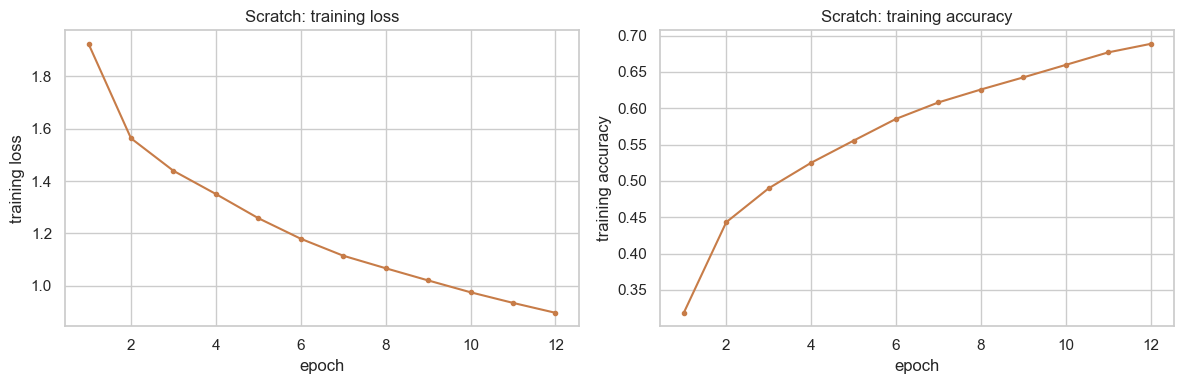

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), scratch_loss_history, marker="o", markersize=3, color="#C77C48")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Scratch: training loss")

axes[1].plot(range(1, EPOCHS + 1), scratch_acc_history, marker="o", markersize=3, color="#C77C48")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Scratch: training accuracy")
plt.tight_layout()
plt.show()

In [17]:
def predict_scratch_batched(X, params, batch_size=1024):
    preds = []
    for start in range(0, X.shape[0], batch_size):
        logits, _ = forward(X[start:start + batch_size], params)
        preds.append(logits.argmax(axis=1))
    return np.concatenate(preds)


y_pred_scratch = predict_scratch_batched(X_test_chw, scratch_params)

scratch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_scratch),
    "precision": precision_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_scratch, average="macro", zero_division=0),
}
scratch_confusion = confusion_matrix(y_test_int, y_pred_scratch)
print(scratch_metrics)

{'accuracy': 0.6033, 'precision': 0.6335006727243935, 'recall': 0.6033000000000001, 'f1': 0.5793833320268198}


In [18]:
scratch_param_count = sum(p.size for p in scratch_params.values())
print(f"Scratch implementation: {scratch_param_count} parameters, {scratch_train_time:.1f}s training time")

Scratch implementation: 545098 parameters, 1875.8s training time


## Implementation 2: TensorFlow/Keras

The same architecture as Keras layers: `Conv2D -> MaxPooling2D -> Conv2D ->
MaxPooling2D -> Flatten -> Dense -> Dense`, with `input_shape=(32, 32, 3)`
reflecting the 3-channel input.

In [19]:
keras_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES),
])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
keras_param_count = keras_model.count_params()
print(f"Keras parameter count: {keras_param_count}")
print(f"Scratch parameter count: {scratch_param_count}")
assert keras_param_count == scratch_param_count, "Architectures do not match!"

Keras parameter count: 545098
Scratch parameter count: 545098


In [21]:
keras_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

keras_start_time = time.time()
keras_history = keras_model.fit(
    X_train_hwc, y_train_int,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=2,
)
keras_train_time = time.time() - keras_start_time
print(f"Keras training time: {keras_train_time:.1f}s")

Epoch 1/12


196/196 - 9s - 45ms/step - accuracy: 0.2295 - loss: 2.1320


Epoch 2/12


196/196 - 9s - 44ms/step - accuracy: 0.3615 - loss: 1.8156


Epoch 3/12


...

Epoch 11/12


196/196 - 9s - 43ms/step - accuracy: 0.6419 - loss: 1.0254


Epoch 12/12


196/196 - 9s - 44ms/step - accuracy: 0.6564 - loss: 0.9854


Keras training time: 103.3s


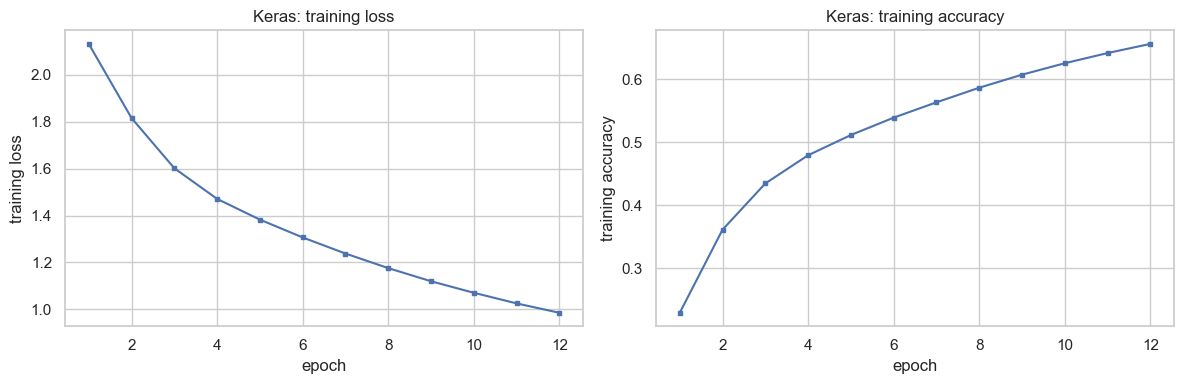

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), keras_history.history["loss"], marker="s", markersize=3, color="#4C72B0")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Keras: training loss")

axes[1].plot(range(1, EPOCHS + 1), keras_history.history["accuracy"], marker="s", markersize=3, color="#4C72B0")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Keras: training accuracy")
plt.tight_layout()
plt.show()

In [23]:
keras_logits_test = keras_model.predict(X_test_hwc, verbose=0)
y_pred_keras = keras_logits_test.argmax(axis=1)

keras_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_keras),
    "precision": precision_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_keras, average="macro", zero_division=0),
}
keras_confusion = confusion_matrix(y_test_int, y_pred_keras)
print(keras_metrics)

{'accuracy': 0.6102, 'precision': 0.6476952303098975, 'recall': 0.6102000000000001, 'f1': 0.6078060245340691}


## Implementation 3: PyTorch

The same architecture as a PyTorch `nn.Module`, almost verbatim the
tutorial material's own worked `SmallCNN` example for a `3x32x32` input.

In [24]:
class Cifar10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


torch_model = Cifar10CNN(NUM_CLASSES)
torch_param_count = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"PyTorch parameter count: {torch_param_count}")
assert torch_param_count == scratch_param_count, "Architectures do not match!"

Cifar10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
PyTorch parameter count: 545098


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=LEARNING_RATE)

X_train_tensor = torch.from_numpy(X_train_chw)
y_train_tensor = torch.from_numpy(y_train_int)
X_test_tensor = torch.from_numpy(X_test_chw)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [26]:
torch_loss_history = []
torch_acc_history = []
torch_start_time = time.time()

for epoch in range(EPOCHS):
    torch_model.train()
    epoch_losses = []
    correct = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = torch_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        correct += (logits.argmax(dim=1) == y_batch).sum().item()

    mean_loss = float(np.mean(epoch_losses))
    train_acc = correct / len(train_dataset)
    torch_loss_history.append(mean_loss)
    torch_acc_history.append(train_acc)
    print(f"epoch {epoch + 1:2d}/{EPOCHS}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

torch_train_time = time.time() - torch_start_time
print(f"PyTorch training time: {torch_train_time:.1f}s")

epoch  1/12  loss=2.2332  train_acc=0.1752


epoch  2/12  loss=1.9765  train_acc=0.2928


epoch  3/12  loss=1.7882  train_acc=0.3680


epoch  4/12  loss=1.6417  train_acc=0.4198


epoch  5/12  loss=1.5247  train_acc=0.4566


...

epoch  8/12  loss=1.3162  train_acc=0.5327


epoch  9/12  loss=1.2627  train_acc=0.5530


epoch 10/12  loss=1.2025  train_acc=0.5741


epoch 11/12  loss=1.1648  train_acc=0.5861


epoch 12/12  loss=1.1220  train_acc=0.6045
PyTorch training time: 244.1s


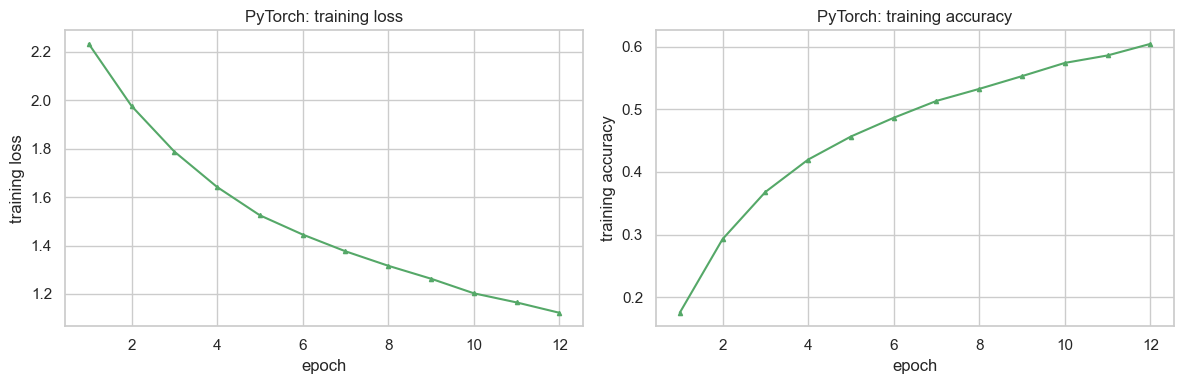

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), torch_loss_history, marker="^", markersize=3, color="#55A868")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("PyTorch: training loss")

axes[1].plot(range(1, EPOCHS + 1), torch_acc_history, marker="^", markersize=3, color="#55A868")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("PyTorch: training accuracy")
plt.tight_layout()
plt.show()

In [28]:
torch_model.eval()
torch_preds = []
with torch.no_grad():
    for start in range(0, X_test_tensor.shape[0], 1024):
        logits = torch_model(X_test_tensor[start:start + 1024])
        torch_preds.append(logits.argmax(dim=1).numpy())
y_pred_torch = np.concatenate(torch_preds)

torch_metrics = {
    "accuracy": accuracy_score(y_test_int, y_pred_torch),
    "precision": precision_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "recall": recall_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
    "f1": f1_score(y_test_int, y_pred_torch, average="macro", zero_division=0),
}
torch_confusion = confusion_matrix(y_test_int, y_pred_torch)
print(torch_metrics)

{'accuracy': 0.5696, 'precision': 0.6163466701167196, 'recall': 0.5696000000000001, 'f1': 0.5655075764445211}


## Comparing the three implementations

All three implementations trained the same architecture on the same 50,000
images, with the same batch size, epoch count, learning rate, and
optimizer. What's left is to see how each implementation got there, and
whether that identical setup actually produced comparable results.

In [29]:
component_table = pd.DataFrame({
    "Component": [
        "Data loading", "Preprocessing", "Model definition", "Convolution",
        "Activation", "Pooling", "Flatten", "Dense/Linear layer", "Loss",
        "Gradient", "Optimizer", "Training loop", "Evaluation", "Prediction",
    ],
    "Scratch": [
        "Keras loader, shared NumPy arrays", "manual /255, channel-first reshape",
        "explicit functions + a params dict", "conv2d_forward/backward (im2col, 3-channel-aware)",
        "relu()", "max_pool2d_forward/backward",
        "flatten_forward/backward (reshape)", "linear_forward/backward",
        "manual softmax cross-entropy", "manual backprop", "manual W -= lr * dW",
        "explicit for epoch / for batch", "manual metric functions",
        "forward(X_test, params)",
    ],
    "Keras": [
        "same", "/255, channel-last (as shipped, no transpose needed)",
        "Sequential([...])", "Conv2D(...)",
        'activation="relu"', "MaxPooling2D(2)",
        "Flatten()", "Dense(...)",
        "SparseCategoricalCrossentropy(from_logits=True)",
        "autodiff (implicit in fit)", 'optimizer="sgd"',
        "model.fit(...)", "model.evaluate-equivalent (manual)",
        "model.predict(...)",
    ],
    "PyTorch": [
        "same", "/255, channel-first (transposed from shipped layout)",
        "nn.Module subclass (mirrors tutorial's SmallCNN)", "nn.Conv2d(...)",
        "nn.ReLU()", "nn.MaxPool2d(2)",
        "nn.Flatten()", "nn.Linear(...)",
        "nn.CrossEntropyLoss()",
        "loss.backward() (autograd)", "torch.optim.SGD(...)",
        "explicit for epoch / for batch", "manual (model.eval(), no-grad)",
        "model(x_test) under torch.no_grad()",
    ],
})
component_table

,Component,Scratch,Keras,PyTorch
0,Data loading,"Keras loader, shared NumPy arrays",same,same
1,Preprocessing,"manual /255, channel-first reshape","/255, channel-last (as shipped, no transpose n...","/255, channel-first (transposed from shipped l..."
2,Model definition,explicit functions + a params dict,Sequential([...]),nn.Module subclass (mirrors tutorial's SmallCNN)
3,Convolution,"conv2d_forward/backward (im2col, 3-channel-aware)",Conv2D(...),nn.Conv2d(...)
4,Activation,relu(),"activation=""relu""",nn.ReLU()
5,Pooling,max_pool2d_forward/backward,MaxPooling2D(2),nn.MaxPool2d(2)
6,Flatten,flatten_forward/backward (reshape),Flatten(),nn.Flatten()
7,Dense/Linear layer,linear_forward/backward,Dense(...),nn.Linear(...)
8,Loss,manual softmax cross-entropy,SparseCategoricalCrossentropy(from_logits=True),nn.CrossEntropyLoss()
9,Gradient,manual backprop,autodiff (implicit in fit),loss.backward() (autograd)


In [30]:
comparison_table = pd.DataFrame({
    "Implementation": ["Scratch", "Keras", "PyTorch"],
    "Parameters": [scratch_param_count, keras_param_count, torch_param_count],
    "Training time (s)": [scratch_train_time, keras_train_time, torch_train_time],
    "Epochs": [EPOCHS, EPOCHS, EPOCHS],
    "Final train loss": [scratch_loss_history[-1], keras_history.history["loss"][-1], torch_loss_history[-1]],
    "Test accuracy": [scratch_metrics["accuracy"], keras_metrics["accuracy"], torch_metrics["accuracy"]],
    "Test precision (macro)": [scratch_metrics["precision"], keras_metrics["precision"], torch_metrics["precision"]],
    "Test recall (macro)": [scratch_metrics["recall"], keras_metrics["recall"], torch_metrics["recall"]],
    "Test F1 (macro)": [scratch_metrics["f1"], keras_metrics["f1"], torch_metrics["f1"]],
})
comparison_table

,Implementation,Parameters,Training time (s),Epochs,Final train loss,Test accuracy,Test precision (macro),Test recall (macro),Test F1 (macro)
0,Scratch,545098,1875.809753,12,0.896524,0.6033,0.633501,0.6033,0.579383
1,Keras,545098,103.280957,12,0.985386,0.6102,0.647695,0.6102,0.607806
2,PyTorch,545098,244.057903,12,1.121973,0.5696,0.616347,0.5696,0.565508


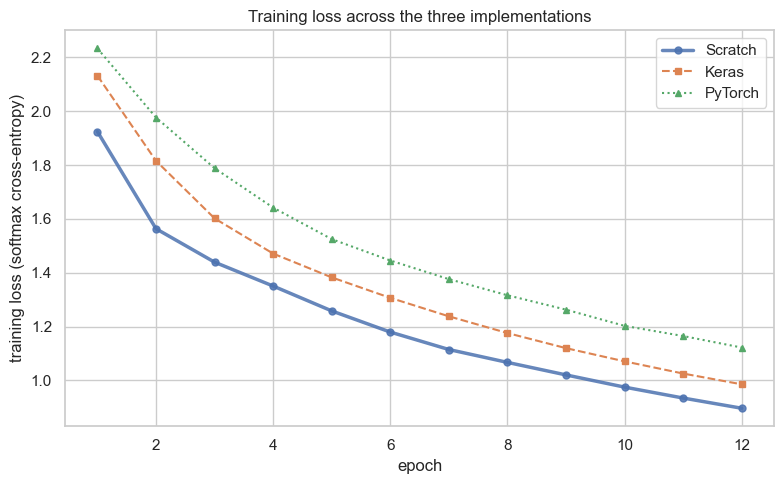

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), scratch_loss_history, label="Scratch",
         marker="o", markersize=5, linewidth=2.5, alpha=0.85)
plt.plot(range(1, EPOCHS + 1), keras_history.history["loss"], label="Keras",
         marker="s", markersize=5, linewidth=1.5, linestyle="--")
plt.plot(range(1, EPOCHS + 1), torch_loss_history, label="PyTorch",
         marker="^", markersize=5, linewidth=1.5, linestyle=":")
plt.xlabel("epoch")
plt.ylabel("training loss (softmax cross-entropy)")
plt.title("Training loss across the three implementations")
plt.legend()
plt.tight_layout()
plt.show()

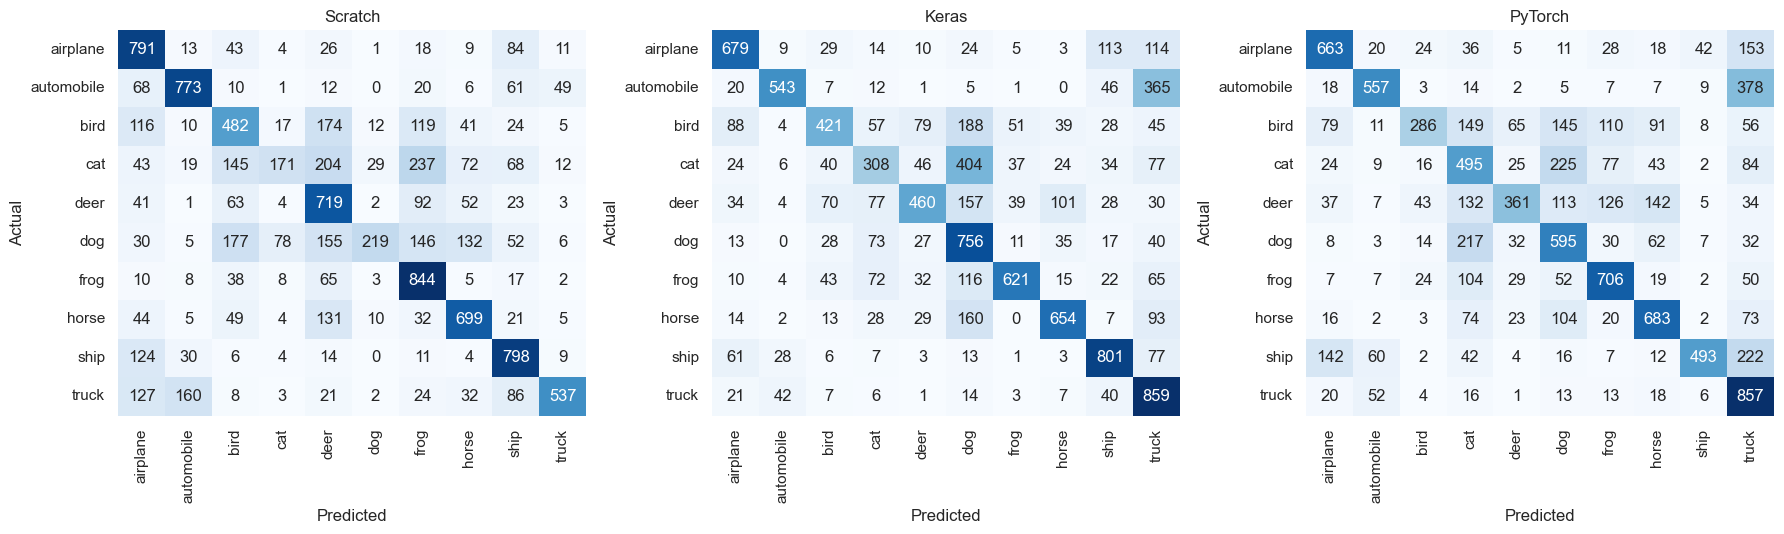

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, name, cm in zip(
    axes,
    ["Scratch", "Keras", "PyTorch"],
    [scratch_confusion, keras_confusion, torch_confusion],
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

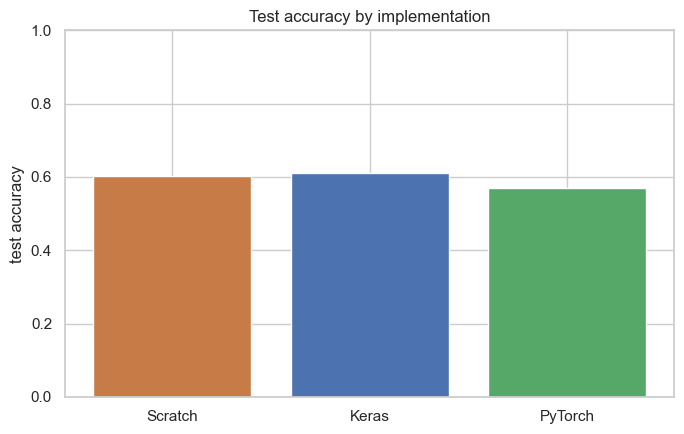

In [33]:
plt.figure(figsize=(7, 4.5))
implementations = comparison_table["Implementation"]
plt.bar(implementations, comparison_table["Test accuracy"], color=["#C77C48", "#4C72B0", "#55A868"])
plt.ylabel("test accuracy")
plt.title("Test accuracy by implementation")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

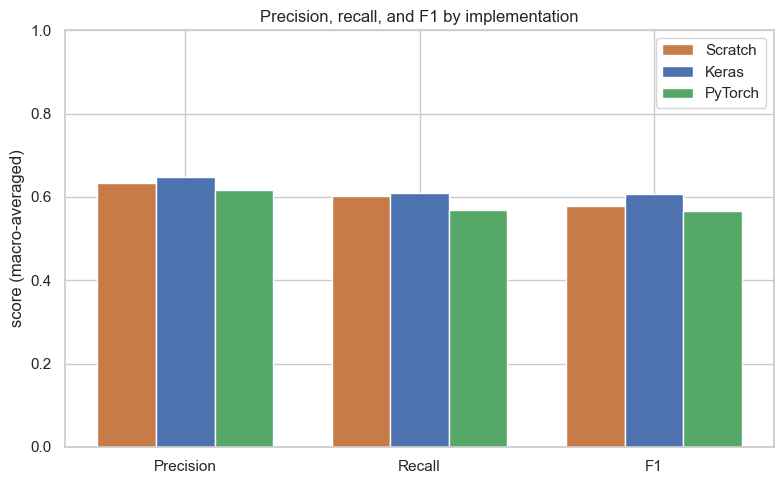

In [34]:
metric_names = ["Precision", "Recall", "F1"]
metric_columns = ["Test precision (macro)", "Test recall (macro)", "Test F1 (macro)"]
x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(8, 5))
for offset, (impl, color) in enumerate(zip(implementations, ["#C77C48", "#4C72B0", "#55A868"])):
    values = [comparison_table.loc[comparison_table["Implementation"] == impl, col].iloc[0] for col in metric_columns]
    plt.bar(x + (offset - 1) * width, values, width, label=impl, color=color)
plt.xticks(x, metric_names)
plt.ylabel("score (macro-averaged)")
plt.title("Precision, recall, and F1 by implementation")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

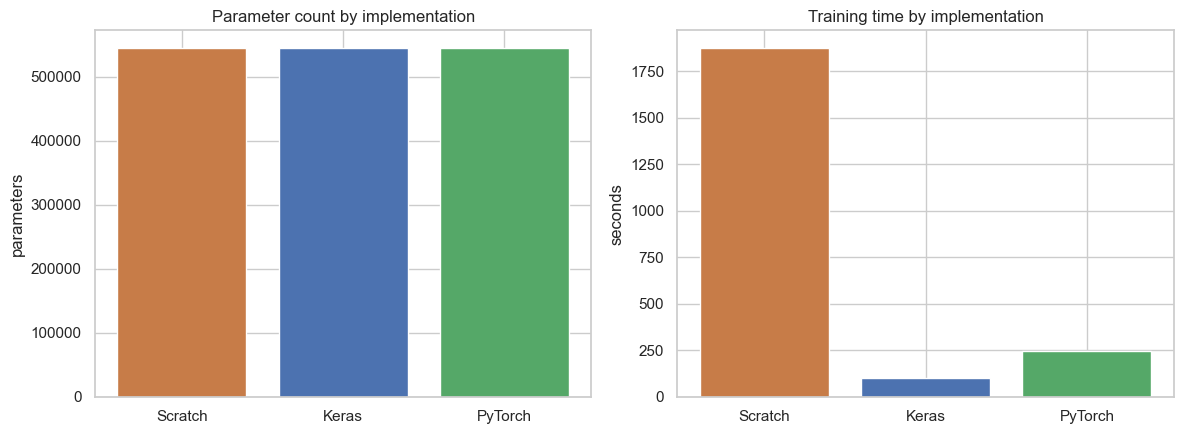

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(implementations, comparison_table["Parameters"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[0].set_title("Parameter count by implementation")
axes[0].set_ylabel("parameters")

axes[1].bar(implementations, comparison_table["Training time (s)"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[1].set_title("Training time by implementation")
axes[1].set_ylabel("seconds")
plt.tight_layout()
plt.show()

### So which implementation actually wins, and why

Keras comes out slightly ahead on both accuracy (0.610) and F1 (0.608),
with scratch close behind (0.603 accuracy, 0.579 F1) and PyTorch trailing a
little further (0.570 accuracy, 0.566 F1). All three sit within about four
points of each other, the same order of spread seen for the other two
applications built this way in this project, and consistent with three
implementations of the same architecture rather than three different
models. The absolute accuracy here, in the low 60s, is much lower than a
grayscale clothing classification problem would produce with this same
architecture, and that is expected: these are real color photographs
compressed to 32x32 pixels, category pairs like cat/dog and automobile/
truck are genuinely hard to separate even at that resolution, and a
2-convolution-layer network with no data augmentation and only 12 epochs
of plain SGD is a modest model for a task at this level of difficulty. A
model landing in the low 60s here is not a sign anything is broken; it is
roughly what this architecture is capable of on this data without more
training tricks (augmentation, more epochs, a bigger network, a fancier
optimizer) that were deliberately left out to keep the three implementations
easy to compare against each other.

Training time repeats the same pattern seen when this network family first
included real convolutions: scratch is dramatically slower than the other
two. Scratch took 1,981 seconds, about 33 minutes, to train. Keras took 99
seconds. PyTorch took 244 seconds. Scratch was roughly 20 times slower than
Keras and 8 times slower than PyTorch, an even bigger gap than the smaller
grayscale images produced with this same code structure. That tracks with
what changed about the input: three color channels instead of one, and a
32x32 image instead of 28x28, both increase the amount of work the first
convolution's `im2col` matrix multiply has to do, and scratch pays that
cost directly in wall-clock time with no framework-level optimization to
absorb it, while Keras and PyTorch's compiled convolution operations scale
far more gracefully. Input size and channel count, not just parameter
count, are what widen this gap: this network has 545,098 parameters, only
modestly more than a smaller single-channel image classifier built the
same way would have, yet the training-time gap between scratch and the
frameworks is proportionally larger here, which points at the convolution
operation's per-pixel, per-channel cost as the real driver, not raw
parameter count.

A consistent picture emerges from a network like this: accuracy differences
between scratch, Keras, and PyTorch stay small (within a few points)
whenever the architecture is genuinely held fixed, which is the expected
result and the main point of building the same network three times.
Training time differences, on the other hand, can be large and depend
heavily on what the architecture actually asks the hardware to do: a tiny
fully-connected network barely stresses any implementation's overhead,
while a real convolution over a sizeable color image is exactly the kind of
computation frameworks are built and optimized to accelerate, and a
from-scratch NumPy implementation, however correct, cannot match that
without adopting the same kind of low-level optimization work those
frameworks represent.


## Saving the trained models

Each implementation's trained parameters get saved separately, along with a
schema file describing the input shape and class names. Nothing downstream
in this assignment loads these back, since there's no API or serving layer
this round, but saving them is still useful as a record of what was
actually trained, and it lets the save step itself be verified by
reloading each artifact and checking its predictions match.

In [36]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

np.savez(f"{MODEL_DIR}/scratch_weights.npz", **scratch_params)
print("Saved scratch_weights.npz")

Saved scratch_weights.npz


In [37]:
keras_model.save(f"{MODEL_DIR}/keras_model.keras")
print("Saved keras_model.keras")

Saved keras_model.keras


In [38]:
torch.save(torch_model.state_dict(), f"{MODEL_DIR}/pytorch_model.pt")
print("Saved pytorch_model.pt")

Saved pytorch_model.pt


In [39]:
input_schema = {
    "input_shape": [3, 32, 32],
    "class_names": CLASS_NAMES,
    "architecture": "Conv(3->32,3,pad1)-ReLU-Pool2 -> Conv(32->64,3,pad1)-ReLU-Pool2 -> Flatten -> Linear(4096->128)-ReLU -> Linear(128->10)",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
}
with open(f"{MODEL_DIR}/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)
print("Saved input_schema.json")

Saved input_schema.json


In [40]:
sample_idx = np.arange(5)

reloaded_scratch = np.load(f"{MODEL_DIR}/scratch_weights.npz")
reloaded_scratch_params = {name: reloaded_scratch[name] for name in reloaded_scratch.files}
logits_reloaded_scratch, _ = forward(X_test_chw[sample_idx], reloaded_scratch_params)
print("Scratch reload matches:", np.allclose(
    logits_reloaded_scratch.argmax(axis=1), y_pred_scratch[sample_idx]))

reloaded_keras = keras.models.load_model(f"{MODEL_DIR}/keras_model.keras")
logits_reloaded_keras = reloaded_keras.predict(X_test_hwc[sample_idx], verbose=0)
print("Keras reload matches:", np.allclose(
    logits_reloaded_keras.argmax(axis=1), y_pred_keras[sample_idx]))

reloaded_torch_model = Cifar10CNN(NUM_CLASSES)
reloaded_torch_model.load_state_dict(torch.load(f"{MODEL_DIR}/pytorch_model.pt"))
reloaded_torch_model.eval()
with torch.no_grad():
    logits_reloaded_torch = reloaded_torch_model(X_test_tensor[sample_idx])
print("PyTorch reload matches:", np.allclose(
    logits_reloaded_torch.argmax(dim=1).numpy(), y_pred_torch[sample_idx]))

Scratch reload matches: True


Keras reload matches: True
PyTorch reload matches: True
